#Read Gold Layer + Feature Engineering

Import Libraries

In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objects as go

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

import warnings
warnings.filterwarnings("ignore")

plt.style.use("ggplot")


Read Gold Layer

In [ ]:
fact_sales_url = "https://raw.githubusercontent.com/DuaA-A/Enterprise-E-Commerce-Predictive-Analytics/refs/heads/main/Medallion%20Architecture/Gold%20Layer/fact_sales.csv"

dim_product_url = "https://raw.githubusercontent.com/DuaA-A/Enterprise-E-Commerce-Predictive-Analytics/refs/heads/main/Medallion%20Architecture/Gold%20Layer/dim_product.csv"

dim_marketplace_url = "https://raw.githubusercontent.com/DuaA-A/Enterprise-E-Commerce-Predictive-Analytics/refs/heads/main/Medallion%20Architecture/Gold%20Layer/dim_marketplace.csv"

dim_date_url = "https://raw.githubusercontent.com/DuaA-A/Enterprise-E-Commerce-Predictive-Analytics/refs/heads/main/Medallion%20Architecture/Gold%20Layer/dim_date.csv"


fact_sales = pd.read_csv(fact_sales_url)

dim_product = pd.read_csv(dim_product_url)

dim_marketplace = pd.read_csv(dim_marketplace_url)

dim_date = pd.read_csv(dim_date_url)



 Check Data



In [ ]:
print("Fact Sales :", fact_sales.shape)
print("Product :", dim_product.shape)
print("Marketplace :", dim_marketplace.shape)
print("Date :", dim_date.shape)
print("="*50)

print("\nFact Sales")
display(fact_sales.head())

print("\nProduct")
display(dim_product.head())

print("\nMarketplace")
display(dim_marketplace.head())

print("\nDate")
display(dim_date.head())

Fact Sales : (13323, 30)
Product : (102, 8)
Marketplace : (5, 3)
Date : (209, 10)

Fact Sales


,Sales_Key,Date_Key,Marketplace_Key,Product_Key,Account Title,Taxes,Orders,Units,Refunded,Refund %,...,Impressions,Clicks,PPC Orders,PPC Sales,PPC Cost,PPC Conv,OOE,Net Profit,Net Margin,Net ROI
0,1,1,1,1,[ UK ] Aava,-50.34,17,17,0,0.0,...,3423,13,2,29.36,-13.06,0.1538,0,56.28,0.1852,0.3142
1,2,2,1,1,[ UK ] Aava,-58.89,20,20,0,0.0,...,2786,7,0,0.00,-7.33,0.0000,0,71.73,0.2034,0.3439
2,3,3,1,1,[ UK ] Aava,-72.41,18,24,0,0.0,...,2927,7,1,14.69,-6.15,0.1429,0,61.37,0.1386,0.2416
3,4,4,1,1,[ UK ] Aava,-41.43,13,14,0,0.0,...,3584,16,2,44.07,-16.51,0.1250,0,39.49,0.1573,0.2684
4,5,5,1,1,[ UK ] Aava,-47.04,16,16,0,0.0,...,4329,7,0,0.00,-4.47,0.0000,0,59.86,0.2116,0.3588



Product


,Product_Key,SKU,FNSKU,ASIN,Parent ASIN,Is Parent,Brand,Title
0,1,UK_Aava_Magnesium_400mg_120_05,X000JJIQ79,B01GU9QLZC,No Parent,0,Aavalabs,High Absorption Magnesium Citrate Supplements ...
1,2,UK_Aava_Omega_2000mg_120_05,X000JFSY57,B01GU9P0M2,No Parent,0,Aavalabs,Omega 3 2000mg Fish Oil Capsules - High Streng...
2,3,UK_Aava_Turmeric_1400mg_120_07,X000J6KEPJ,B01GU8L68A,No Parent,0,Aavalabs,Turmeric Curcumin Capsules with Black Pepper [...
3,4,FR_Aava_Turmeric_1400mg_180_01,X000UL0561,B07CXYM3H5,No Parent,0,Aavalabs,Gélules biodisponibles du complexe de curcumin...
4,5,FR_Aava_Magnesium_400mg_120_01,X000UL0OUX,B07CZ1P4BM,No Parent,0,Aavalabs,"Citrate de Magnésium - 1496 mg dont 448,8 mg d..."



Marketplace


,Marketplace_Key,Market Place,Account Title
0,1,UK,[ UK ] Aava
1,2,FR,[ FR ] Aava
2,3,DE,[ DE ] Aava
3,4,IT,[ IT ] Aava
4,5,ES,[ ES ] Aava



Date


,Date_Key,Date,Day,Month,Month_Name,Quarter,Year,Week_Of_Year,Day_Name,Is_Weekend
0,1,2020-10-01,1,10,October,4,2020,40,Thursday,False
1,2,2020-10-02,2,10,October,4,2020,40,Friday,False
2,3,2020-10-03,3,10,October,4,2020,40,Saturday,True
3,4,2020-10-04,4,10,October,4,2020,40,Sunday,True
4,5,2020-10-05,5,10,October,4,2020,41,Monday,False


Merge Tables

In [ ]:
df = fact_sales.merge(
    dim_product,
    on="Product_Key",
    how="left"
)

df = df.merge(
    dim_marketplace,
    on="Marketplace_Key",
    how="left"
)

df = df.merge(
    dim_date,
    on="Date_Key",
    how="left"
)

print(df.shape)

(13323, 48)


Preview

In [ ]:
display(df.head())

,Sales_Key,Date_Key,Marketplace_Key,Product_Key,Account Title_x,Taxes,Orders,Units,Refunded,Refund %,...,Account Title_y,Date,Day,Month,Month_Name,Quarter,Year,Week_Of_Year,Day_Name,Is_Weekend
0,1,1,1,1,[ UK ] Aava,-50.34,17,17,0,0.0,...,[ UK ] Aava,2020-10-01,1,10,October,4,2020,40,Thursday,False
1,2,2,1,1,[ UK ] Aava,-58.89,20,20,0,0.0,...,[ UK ] Aava,2020-10-02,2,10,October,4,2020,40,Friday,False
2,3,3,1,1,[ UK ] Aava,-72.41,18,24,0,0.0,...,[ UK ] Aava,2020-10-03,3,10,October,4,2020,40,Saturday,True
3,4,4,1,1,[ UK ] Aava,-41.43,13,14,0,0.0,...,[ UK ] Aava,2020-10-04,4,10,October,4,2020,40,Sunday,True
4,5,5,1,1,[ UK ] Aava,-47.04,16,16,0,0.0,...,[ UK ] Aava,2020-10-05,5,10,October,4,2020,41,Monday,False


Check After Merge

In [ ]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13323 entries, 0 to 13322
Data columns (total 48 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Sales_Key         13323 non-null  int64  
 1   Date_Key          13323 non-null  int64  
 2   Marketplace_Key   13323 non-null  int64  
 3   Product_Key       13323 non-null  int64  
 4   Account Title_x   13323 non-null  object 
 5   Taxes             13323 non-null  float64
 6   Orders            13323 non-null  int64  
 7   Units             13323 non-null  int64  
 8   Refunded          13323 non-null  int64  
 9   Refund %          13323 non-null  float64
 10  Unit Session %    13323 non-null  float64
 11  Promo Units       13323 non-null  int64  
 12  Organic Units     13323 non-null  int64  
 13  Per Unit Revenue  13323 non-null  float64
 14  Revenue           13323 non-null  float64
 15  COGS              13323 non-null  float64
 16  FBA Fees          13323 non-null  float6

In [ ]:
print("Missing Values :",df.isnull().sum())

print("Duplicate Rows :", df.duplicated().sum())


Missing Values : Sales_Key           0
Date_Key            0
Marketplace_Key     0
Product_Key         0
Account Title_x     0
Taxes               0
Orders              0
Units               0
Refunded            0
Refund %            0
Unit Session %      0
Promo Units         0
Organic Units       0
Per Unit Revenue    0
Revenue             0
COGS                0
FBA Fees            0
Promo Amount        0
Sessions            0
Page Views          0
Impressions         0
Clicks              0
PPC Orders          0
PPC Sales           0
PPC Cost            0
PPC Conv            0
OOE                 0
Net Profit          0
Net Margin          0
Net ROI             0
SKU                 0
FNSKU               0
ASIN                0
Parent ASIN         0
Is Parent           0
Brand               0
Title               0
Market Place        0
Account Title_y     0
Date                0
Day                 0
Month               0
Month_Name          0
Quarter             0
Year           


change Date Column data type



In [ ]:
df["Date"] = pd.to_datetime(df["Date"], errors="coerce")


print(df["Date"].dtype)
print("Invalid dates:", df["Date"].isna().sum())

datetime64[ns]
Invalid dates: 0


Time Features

In [ ]:
df["Year"] = df["Date"].dt.year

df["Month"] = df["Date"].dt.month

df["Month_Name"] = df["Date"].dt.month_name()

df["Quarter"] = df["Date"].dt.quarter

df["Week"] = df["Date"].dt.isocalendar().week.astype(int)

df["Day"] = df["Date"].dt.day

df["Day_Name"] = df["Date"].dt.day_name()

df["Weekend"] = df["Day_Name"].isin(
    ["Saturday","Sunday"]
).astype(int)

Business Features

In [ ]:
df["Conversion_Rate"] = (
    df["Units"] /
    df["Sessions"]
)

df["CTR"] = (
    df["Clicks"] /
    df["Impressions"]
)

df["CPC"] = (
    df["PPC Cost"] /
    df["Clicks"]
)

df["Revenue_Per_Click"] = (
    df["Revenue"] /
    df["Clicks"]
)

df["Revenue_Per_Session"] = (
    df["Revenue"] /
    df["Sessions"]
)

df["Profit_Margin"] = (
    df["Net Profit"] /
    df["Revenue"]
)

df["AOV"] = (
    df["Revenue"] /
    df["Orders"]
)

df["Refund_Rate"] = (
    df["Refunded"] /
    df["Revenue"]
)

Replace Infinity

In [ ]:
df.replace(
    [np.inf,-np.inf],
    0,
    inplace=True
)

df.fillna(0,inplace=True)

 Rolling Features

In [ ]:
df = df.sort_values(["Product_Key","Date"])

df["Revenue_7D"] = (
    df.groupby("Product_Key")["Revenue"]
    .transform(lambda x:x.rolling(7,min_periods=1).mean())
)

df["Revenue_30D"] = (
    df.groupby("Product_Key")["Revenue"]
    .transform(lambda x:x.rolling(30,min_periods=1).mean())
)

df["Profit_7D"] = (
    df.groupby("Product_Key")["Net Profit"]
    .transform(lambda x:x.rolling(7,min_periods=1).mean())
)

df["Orders_7D"] = (
    df.groupby("Product_Key")["Orders"]
    .transform(lambda x:x.rolling(7,min_periods=1).mean())
)

Lag Features

In [ ]:
df["Revenue_Lag1"] = (
    df.groupby("Product_Key")["Revenue"]
    .shift(1)
)

df["Revenue_Lag7"] = (
    df.groupby("Product_Key")["Revenue"]
    .shift(7)
)

df["Profit_Lag1"] = (
    df.groupby("Product_Key")["Net Profit"]
    .shift(1)
)

df["Orders_Lag1"] = (
    df.groupby("Product_Key")["Orders"]
    .shift(1)
)

Growth Features

In [ ]:
df["Revenue_Growth"] = (
    (df["Revenue"]-df["Revenue_Lag1"])
    /(df["Revenue_Lag1"]+1)
)

df["Profit_Growth"] = (
    (df["Net Profit"]-df["Profit_Lag1"])
    /(df["Profit_Lag1"]+1)
)

df["Orders_Growth"] = (
    (df["Orders"]-df["Orders_Lag1"])
    /(df["Orders_Lag1"]+1)
)

Feature Cleaning

In [ ]:
df.fillna(0,inplace=True)

Final Shape

In [ ]:
print("="*50)
print(df.shape)
print("="*50)

display(df.head())

(13323, 69)


,Sales_Key,Date_Key,Marketplace_Key,Product_Key,Account Title_x,Taxes,Orders,Units,Refunded,Refund %,...,Revenue_30D,Profit_7D,Orders_7D,Revenue_Lag1,Revenue_Lag7,Profit_Lag1,Orders_Lag1,Revenue_Growth,Profit_Growth,Orders_Growth
0,1,1,1,1,[ UK ] Aava,-50.34,17,17,0,0.0,...,303.940000,56.280000,17.000000,0.00,0.0,0.00,0.0,0.000000,0.000000,0.000000
1,2,2,1,1,[ UK ] Aava,-58.89,20,20,0,0.0,...,328.320000,64.005000,18.500000,303.94,0.0,56.28,17.0,0.159900,0.269728,0.166667
2,3,3,1,1,[ UK ] Aava,-72.41,18,24,0,0.0,...,366.476667,63.126667,18.333333,352.70,0.0,71.73,20.0,0.254707,-0.142445,-0.095238
3,4,4,1,1,[ UK ] Aava,-41.43,13,14,0,0.0,...,337.610000,57.217500,17.000000,442.79,0.0,61.37,18.0,-0.432141,-0.350810,-0.263158
4,5,5,1,1,[ UK ] Aava,-47.04,16,16,0,0.0,...,326.680000,57.746000,16.800000,251.01,0.0,39.49,13.0,0.126781,0.503087,0.214286


Save ML Dataset

In [ ]:
df.to_csv("ml_ready_data.csv",index=False)

print("ML Dataset Saved Successfully")

ML Dataset Saved Successfully


#Data Preparation For Machine Learning

In [ ]:
# Remove Infinity Values
df.replace([np.inf, -np.inf], np.nan, inplace=True)

# Fill Missing Values
df.fillna(0, inplace=True)


# Outlier Treatment (IQR Clipping)

import numpy as np

numeric_cols = [
    "Revenue",
    "Orders",
    "Net Profit",
    "Net Margin",
    "Net ROI"
]

for col in numeric_cols:

    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    df[col] = df[col].clip(lower, upper)

print("✅ Outliers treated successfully.")

print("Dataset Shape :", df.shape)




✅ Outliers treated successfully.
Dataset Shape : (13323, 69)


In [ ]:
print(df.info())

numeric_columns = df.select_dtypes(include=np.number).columns

print("\nNumeric Columns\n")
print(numeric_columns)

display(df.describe().T)

<class 'pandas.core.frame.DataFrame'>
Index: 13323 entries, 0 to 13140
Data columns (total 69 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   Sales_Key            13323 non-null  int64         
 1   Date_Key             13323 non-null  int64         
 2   Marketplace_Key      13323 non-null  int64         
 3   Product_Key          13323 non-null  int64         
 4   Account Title_x      13323 non-null  object        
 5   Taxes                13323 non-null  float64       
 6   Orders               13323 non-null  int64         
 7   Units                13323 non-null  int64         
 8   Refunded             13323 non-null  int64         
 9   Refund %             13323 non-null  float64       
 10  Unit Session %       13323 non-null  float64       
 11  Promo Units          13323 non-null  int64         
 12  Organic Units        13323 non-null  int64         
 13  Per Unit Revenue     13323 non-null 

,count,mean,min,25%,50%,75%,max,std
Sales_Key,13323.0,6662.0,1.0,3331.5,6662.0,9992.5,13323.0,3846.163153
Date_Key,13323.0,106.820011,1.0,54.0,108.0,160.0,209.0,60.47618
Marketplace_Key,13323.0,3.011409,1.0,2.0,3.0,4.0,5.0,1.417455
Product_Key,13323.0,50.032425,1.0,26.0,48.0,80.0,102.0,30.231676
Taxes,13323.0,-21.696464,-1168.65,-25.19,-9.46,-1.98,0.0,35.902825
Orders,13323.0,9.762216,0.0,2.0,7.0,14.0,32.0,9.597244
Units,13323.0,13.298581,0.0,3.0,8.0,16.0,975.0,20.305648
Refunded,13323.0,0.25865,0.0,0.0,0.0,0.0,42.0,1.237357
Refund %,13323.0,0.017083,0.0,0.0,0.0,0.0,1.0556,0.080636
Unit Session %,13323.0,0.134443,0.0,0.0,0.0,0.25,7.0,0.221282


#KPI'S

In [ ]:
total_revenue = df["Revenue"].sum()

total_profit = df["Net Profit"].sum()

total_orders = df["Orders"].sum()


average_margin = (total_profit / total_revenue) * 100


average_roi = df["Net ROI"].mean()

detected_anomalies = 0
print("="*60)
print("EXECUTIVE KPIs")
print("="*60)

print(f"Total Revenue       : ${total_revenue:,.2f}")
print(f"Total Net Profit    : ${total_profit:,.2f}")
print(f"Total Orders        : {total_orders:,.0f}")
print(f"Average Net Margin  : {average_margin:.2f}%")
print(f"Average ROI         : {average_roi:.2f}%")
print(f"Detected Anomalies  : {detected_anomalies}")

print("="*60)


EXECUTIVE KPIs
Total Revenue       : $3,009,173.99
Total Net Profit    : $582,482.10
Total Orders        : 130,062
Average Net Margin  : 19.36%
Average ROI         : 0.29%
Detected Anomalies  : 0


#Anomaly Detection Model

Libararies

In [ ]:
from sklearn.ensemble import IsolationForest
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
import joblib
from sklearn.decomposition import PCA

Select Features

In [ ]:
features = [

    "Revenue",

    "Orders",

    "Units",

    "Sessions",

    "Clicks",

    "Impressions",

    "PPC Cost",

    "PPC Orders",

    "PPC Sales",

    "FBA Fees",

    "Promo Amount",

    "Refunded",

    "Refund %",

    "Net Profit",

    "Net Margin",

    "Net ROI",

    "Conversion_Rate",

    "CTR",

    "CPC",

    "Revenue_Per_Click",

    "Revenue_Per_Session",

    "AOV",

    "Revenue_7D",

    "Revenue_30D",

    "Profit_7D",

    "Orders_7D",

    "Revenue_Growth",

    "Profit_Growth",

    "Orders_Growth"

]

X = df[features]

Scaling

In [ ]:
pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", IsolationForest(
        n_estimators=500,
        contamination="auto",
        random_state=42,
        n_jobs=-1
    ))
])

pipeline.fit(X)
model = pipeline.named_steps["model"]
X_scaled = pipeline.named_steps["scaler"].transform(X)

joblib.dump(pipeline,"anomaly_detection_pipeline.pkl")
print("Pipeline trained and saved.")

Pipeline trained and saved.


Train Isolation Forest

In [ ]:
model = IsolationForest(

    n_estimators=300,

    contamination=0.05,

    random_state=42

)

model.fit(X_scaled)

IsolationForest(contamination=0.05, n_estimators=300, random_state=42)

Prediction

In [ ]:
pred = model.predict(X_scaled)
df["Anomaly_Score"] = -model.score_samples(X_scaled)

threshold = df["Anomaly_Score"].quantile(0.98)
df["Anomaly"] = (df["Anomaly_Score"]>=threshold).astype(int)

levels=pd.qcut(df["Anomaly_Score"],4,labels=["Low Risk","Medium Risk","High Risk","Critical"])
df["Alert_Level"]=levels

display(df.head())

,Sales_Key,Date_Key,Marketplace_Key,Product_Key,Account Title_x,Taxes,Orders,Units,Refunded,Refund %,...,Revenue_Lag1,Revenue_Lag7,Profit_Lag1,Orders_Lag1,Revenue_Growth,Profit_Growth,Orders_Growth,Anomaly_Score,Anomaly,Alert_Level
0,1,1,1,1,[ UK ] Aava,-50.34,17,17,0,0.0,...,0.00,0.0,0.00,0.0,0.000000,0.000000,0.000000,0.364937,0,Low Risk
1,2,2,1,1,[ UK ] Aava,-58.89,20,20,0,0.0,...,303.94,0.0,56.28,17.0,0.159900,0.269728,0.166667,0.378155,0,Medium Risk
2,3,3,1,1,[ UK ] Aava,-72.41,18,24,0,0.0,...,352.70,0.0,71.73,20.0,0.254707,-0.142445,-0.095238,0.392430,0,High Risk
3,4,4,1,1,[ UK ] Aava,-41.43,13,14,0,0.0,...,442.79,0.0,61.37,18.0,-0.432141,-0.350810,-0.263158,0.360394,0,Low Risk
4,5,5,1,1,[ UK ] Aava,-47.04,16,16,0,0.0,...,251.01,0.0,39.49,13.0,0.126781,0.503087,0.214286,0.367690,0,Medium Risk


Score

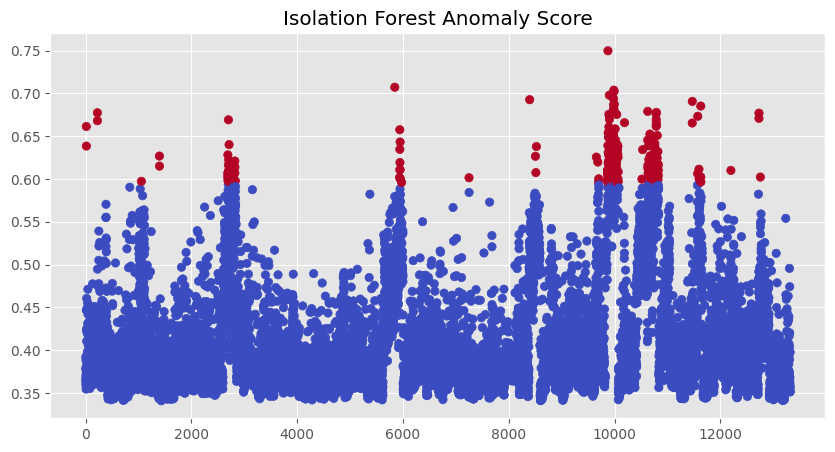

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.scatter(
    df.index,
    df["Anomaly_Score"],
    c=df["Anomaly"],
    cmap="coolwarm"
)

plt.title("Isolation Forest Anomaly Score")

plt.show()

### PCA Visualization

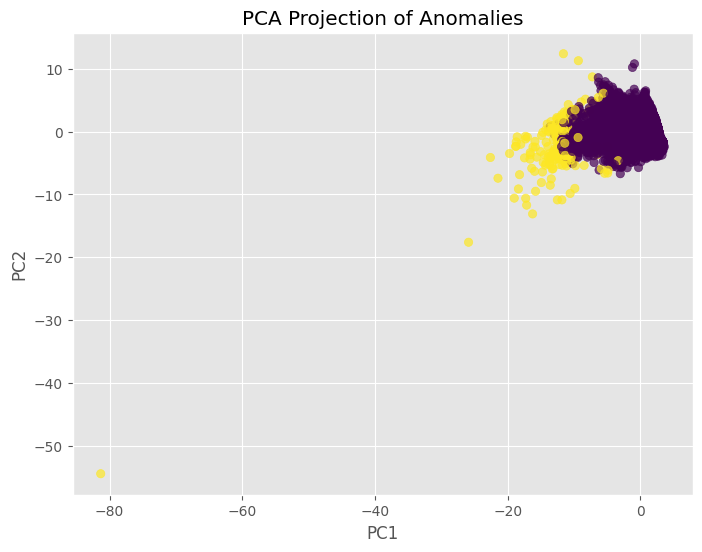

In [ ]:
pca=PCA(n_components=2,random_state=42)
coords=pca.fit_transform(X_scaled)
plt.figure(figsize=(8,6))
plt.scatter(coords[:,0],coords[:,1],c=df["Anomaly"],alpha=0.7)
plt.title("PCA Projection of Anomalies")
plt.xlabel("PC1"); plt.ylabel("PC2")
plt.show()

Save the final dataset

In [ ]:
from google.colab import files


file_name = "ML_Results.xlsx"

df.to_excel(
    file_name,
    index=False
)

print("✅ Excel file saved successfully.")

files.download(file_name)

✅ Excel file saved successfully.


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Update KPI

In [ ]:

detected_anomalies = df["Anomaly"].sum()

print("Detected Anomalies :",detected_anomalies)

Detected Anomalies : 267


Top Anomalies

In [ ]:
top_anomalies = (

    df[df["Anomaly"]==1]

    .sort_values("Anomaly_Score",ascending=False)

)

display(

    top_anomalies[

        [

            "Account Title_x",

            "Market Place",

            "Revenue",

            "Net Profit",

            "Net Margin",

            "Anomaly_Score"

        ]

    ].head(20)

)

,Account Title_x,Market Place,Revenue,Net Profit,Net Margin,Anomaly_Score
9875,[ DE ] Aava,DE,736.5075,154.7125,0.1100,0.749848
5844,[ ES ] Aava,ES,736.5075,154.7125,0.0558,0.707273
9986,[ DE ] Aava,DE,736.5075,154.7125,0.1477,0.703853
9991,[ DE ] Aava,DE,736.5075,154.7125,0.1389,0.702332
9901,[ DE ] Aava,DE,736.5075,154.7125,0.1246,0.697988
9980,[ DE ] Aava,DE,736.5075,154.7125,0.3878,0.694017
8395,[ ES ] Aava,ES,736.5075,154.7125,0.1533,0.692748
11470,[ IT ] Aava,IT,736.5075,-84.2675,-0.0236,0.690750
9990,[ DE ] Aava,DE,736.5075,154.7125,0.1091,0.688087
9988,[ DE ] Aava,DE,736.5075,154.7125,0.1587,0.687161


Revenue Trend With Anomalies

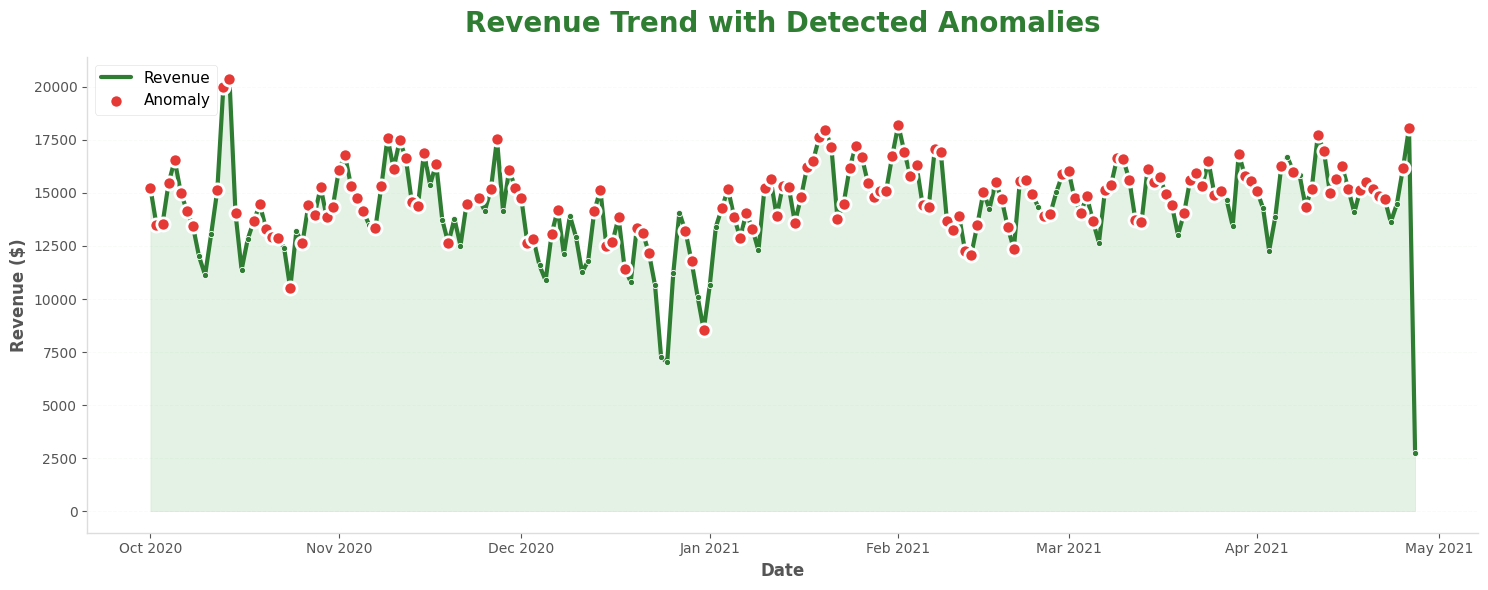

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from google.colab import files

# ==========================
# Colors
# ==========================
GREEN = "#2E7D32"
GREEN_LIGHT = "#66BB6A"
RED = "#E53935"
BG = "#FFFFFF"
GRID = "#EEF5EE"

# ==========================
# Aggregate Revenue by Date
# ==========================
daily = (
    df.groupby("Date")
      .agg({
          "Revenue": "sum",
          "Anomaly": "max"
      })
      .reset_index()
      .sort_values("Date")
)

anomaly_days = daily[daily["Anomaly"] == 1]

# ==========================
# Figure
# ==========================
fig, ax = plt.subplots(figsize=(15,6), facecolor=BG)

ax.set_facecolor(BG)

# Revenue Area
ax.fill_between(
    daily["Date"],
    daily["Revenue"],
    color=GREEN_LIGHT,
    alpha=0.18
)

# Revenue Line
ax.plot(
    daily["Date"],
    daily["Revenue"],
    color=GREEN,
    linewidth=3,
    solid_capstyle="round",
    label="Revenue"
)

# Revenue Points
ax.scatter(
    daily["Date"],
    daily["Revenue"],
    color=GREEN,
    s=20,
    edgecolors="white",
    linewidth=0.6,
    zorder=3
)

# Anomaly Points
ax.scatter(
    anomaly_days["Date"],
    anomaly_days["Revenue"],
    color=RED,
    s=90,
    edgecolors="white",
    linewidth=2,
    zorder=5,
    label="Anomaly"
)

# Title
ax.set_title(
    "Revenue Trend with Detected Anomalies",
    fontsize=20,
    fontweight="bold",
    color=GREEN,
    pad=18
)

# Labels
ax.set_xlabel("Date", fontsize=12, fontweight="bold")
ax.set_ylabel("Revenue ($)", fontsize=12, fontweight="bold")

# Date Format
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))

plt.xticks(rotation=0)

# Grid
ax.grid(
    axis="y",
    linestyle="--",
    linewidth=0.7,
    alpha=0.35,
    color=GRID
)

# Borders
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_color("#DDDDDD")
ax.spines["bottom"].set_color("#DDDDDD")

# Legend
legend = ax.legend(
    loc="upper left",
    frameon=True,
    fontsize=11
)

legend.get_frame().set_facecolor("white")
legend.get_frame().set_edgecolor("#DDDDDD")

plt.tight_layout()

# ==========================
# Save High Quality Image
# ==========================
file_name = "Revenue_Trend.png"

plt.savefig(
    file_name,
    dpi=600,
    bbox_inches="tight",
    facecolor="white"
)

plt.show()
plt.close(fig)

# ==========================
# Download Image
# ==========================
files.download(file_name)

Anomaly Distribution

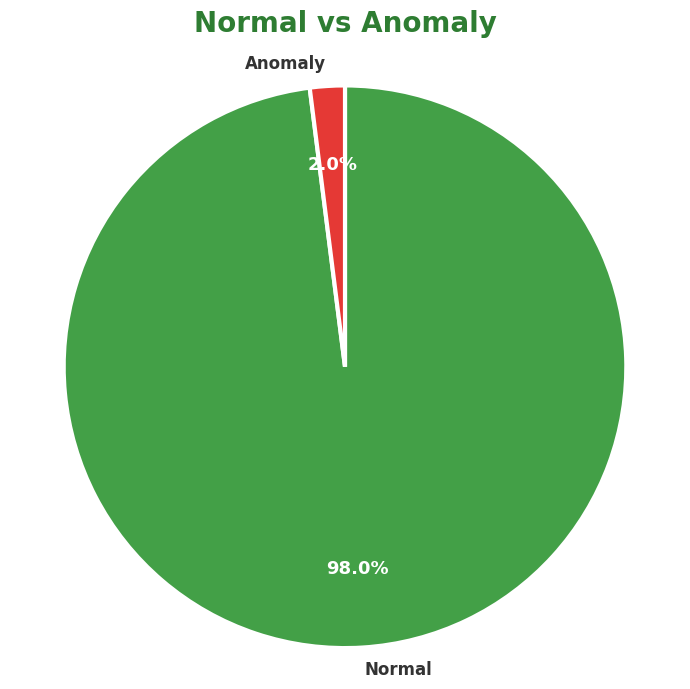

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import matplotlib.pyplot as plt
from google.colab import files

# ==========================
# Colors
# ==========================
GREEN = "#43A047"
GREEN_DARK = "#2E7D32"
RED = "#E53935"
BG = "#FFFFFF"

# ==========================
# Data
# ==========================
counts = (
    df["Anomaly"]
    .value_counts()
    .reindex([0, 1], fill_value=0)
)

labels = ["Normal", "Anomaly"]
colors = [GREEN, RED]

# ==========================
# Figure
# ==========================
fig, ax = plt.subplots(figsize=(7,7), facecolor=BG)

ax.set_facecolor(BG)

# Pie Chart
wedges, texts, autotexts = ax.pie(
    counts,
    labels=labels,
    colors=colors,
    startangle=90,
    counterclock=False,
    autopct="%1.1f%%",
    pctdistance=0.72,
    labeldistance=1.08,
    wedgeprops=dict(
        edgecolor="white",
        linewidth=3
    ),
    textprops=dict(
        fontsize=12,
        fontweight="bold",
        color="#333333"
    )
)

# Style Percentage Text
for txt in autotexts:
    txt.set_color("white")
    txt.set_fontsize(13)
    txt.set_fontweight("bold")

# ==========================
# Title
# ==========================
ax.set_title(
    "Normal vs Anomaly",
    fontsize=20,
    fontweight="bold",
    color=GREEN_DARK,
    pad=20
)

# Perfect Circle
ax.axis("equal")

# Save Image
plt.tight_layout()

file_name = "Normal_vs_Anomaly.png"

plt.savefig(
    file_name,
    dpi=600,
    bbox_inches="tight",
    facecolor="white"
)

plt.show()
plt.close(fig)

# Download
files.download(file_name)

Top 10 Anomalous Products

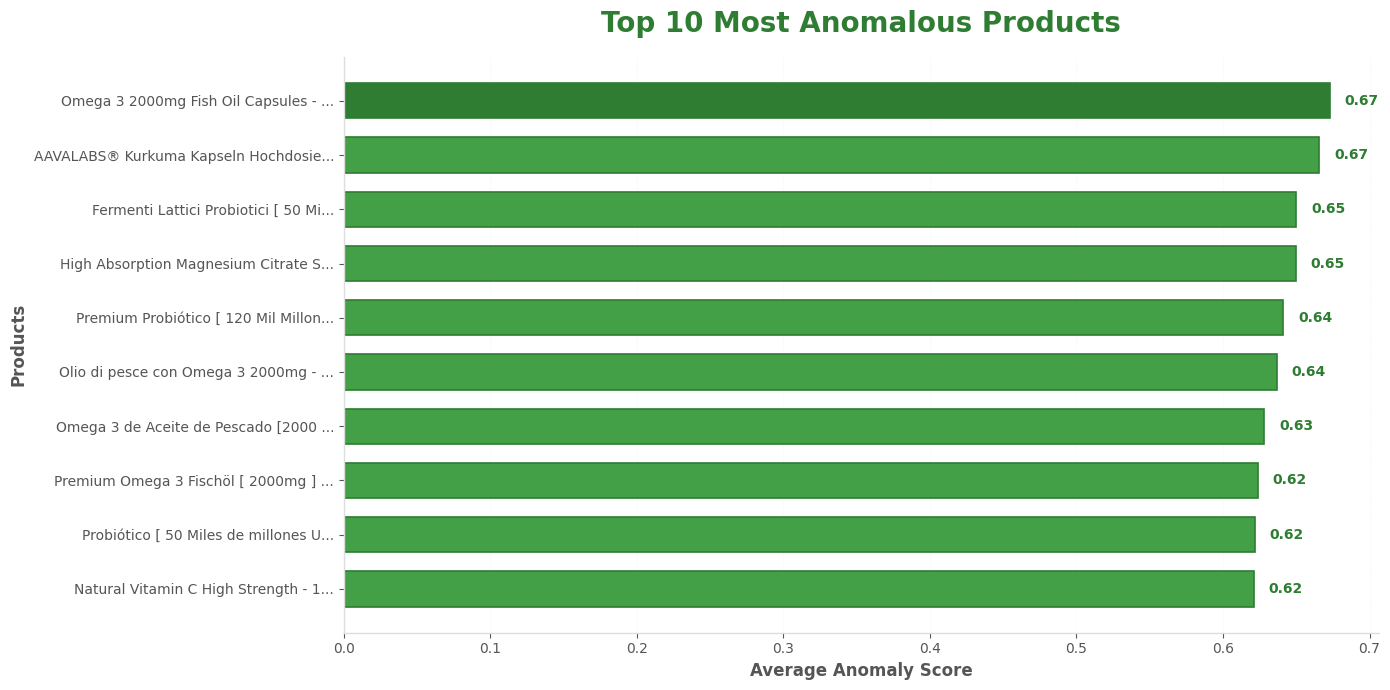

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import matplotlib.pyplot as plt
from google.colab import files

# ==========================
# Colors
# ==========================
GREEN = "#43A047"
GREEN_DARK = "#2E7D32"
GREEN_LIGHT = "#A5D6A7"
BG = "#FFFFFF"
GRID = "#E8F5E9"

# ==========================
# Prepare Data
# ==========================
top10 = (
    df[df["Anomaly"] == 1]
    .groupby("Title")["Anomaly_Score"]
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

# Short Product Names
top10.index = [
    title[:35] + "..." if len(title) > 35 else title
    for title in top10.index
]

# Sort for Horizontal Bars
top10 = top10.sort_values()

# ==========================
# Figure
# ==========================
fig, ax = plt.subplots(figsize=(14,7), facecolor=BG)

ax.set_facecolor(BG)

# Bars
bars = ax.barh(
    top10.index,
    top10.values,
    color=GREEN,
    edgecolor=GREEN_DARK,
    linewidth=1.2,
    height=0.65
)

# Highlight Top Bar
bars[-1].set_color(GREEN_DARK)

# ==========================
# Value Labels
# ==========================
for bar in bars:
    width = bar.get_width()

    ax.text(
        width + 0.01,
        bar.get_y() + bar.get_height()/2,
        f"{width:.2f}",
        va="center",
        fontsize=10,
        fontweight="bold",
        color=GREEN_DARK
    )

# ==========================
# Title
# ==========================
ax.set_title(
    "Top 10 Most Anomalous Products",
    fontsize=20,
    fontweight="bold",
    color=GREEN_DARK,
    pad=18
)

# ==========================
# Labels
# ==========================
ax.set_xlabel(
    "Average Anomaly Score",
    fontsize=12,
    fontweight="bold"
)

ax.set_ylabel(
    "Products",
    fontsize=12,
    fontweight="bold"
)

# ==========================
# Grid
# ==========================
ax.grid(
    axis="x",
    linestyle="--",
    linewidth=0.7,
    alpha=0.35,
    color=GRID
)

# ==========================
# Remove Borders
# ==========================
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.spines["left"].set_color("#DDDDDD")
ax.spines["bottom"].set_color("#DDDDDD")

# ==========================
# Tick Style
# ==========================
ax.tick_params(axis='x', labelsize=10)
ax.tick_params(axis='y', labelsize=10)

plt.tight_layout()

# ==========================
# Save Image
# ==========================
file_name = "Top_10_Most_Anomalous_Products.png"

plt.savefig(
    file_name,
    dpi=600,
    bbox_inches="tight",
    facecolor="white"
)

plt.show()
plt.close(fig)

# ==========================
# Download Image
# ==========================
files.download(file_name)

Monthly Revenue Trend

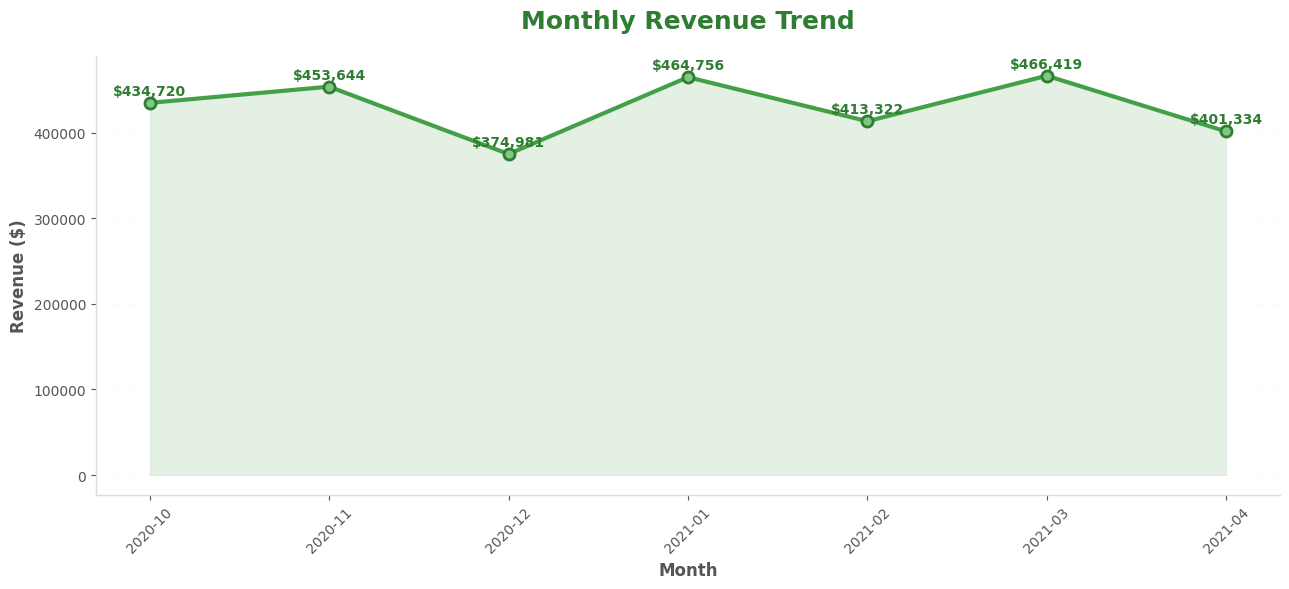

In [ ]:
import matplotlib.pyplot as plt

# ==========================
# Colors
# ==========================
GREEN = "#43A047"
GREEN_DARK = "#2E7D32"
GREEN_LIGHT = "#81C784"
BG = "#FFFFFF"
GRID = "#E8F5E9"

# ==========================
# Prepare Data
# ==========================
monthly = df.groupby(df["Date"].dt.to_period("M"))["Revenue"].sum()
monthly.index = monthly.index.astype(str)

# ==========================
# Plot
# ==========================
plt.figure(figsize=(13,6), facecolor=BG)

ax = plt.gca()
ax.set_facecolor(BG)

# Revenue Line
plt.plot(
    monthly.index,
    monthly.values,
    color=GREEN,
    linewidth=3,
    marker="o",
    markersize=8,
    markerfacecolor=GREEN_LIGHT,
    markeredgecolor=GREEN_DARK,
    markeredgewidth=2
)

# Fill Area
plt.fill_between(
    monthly.index,
    monthly.values,
    color=GREEN,
    alpha=0.15
)

# Value Labels
for x, y in zip(monthly.index, monthly.values):
    plt.text(
        x,
        y + monthly.values.max() * 0.02,
        f"${y:,.0f}",
        ha="center",
        fontsize=10,
        color=GREEN_DARK,
        fontweight="bold"
    )

# ==========================
# Title
# ==========================
plt.title(
    "Monthly Revenue Trend",
    fontsize=18,
    fontweight="bold",
    color=GREEN_DARK,
    pad=20
)

# ==========================
# Labels
# ==========================
plt.xlabel(
    "Month",
    fontsize=12,
    fontweight="bold"
)

plt.ylabel(
    "Revenue ($)",
    fontsize=12,
    fontweight="bold"
)

# ==========================
# Grid
# ==========================
plt.grid(
    axis="y",
    linestyle="--",
    linewidth=0.7,
    alpha=0.35,
    color=GRID
)

# ==========================
# Remove Extra Borders
# ==========================
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.spines["left"].set_color("#DDDDDD")
ax.spines["bottom"].set_color("#DDDDDD")

# ==========================
# Tick Style
# ==========================
plt.xticks(rotation=45, fontsize=10)
plt.yticks(fontsize=10)

plt.tight_layout()

plt.show()

Revenue vs Orders

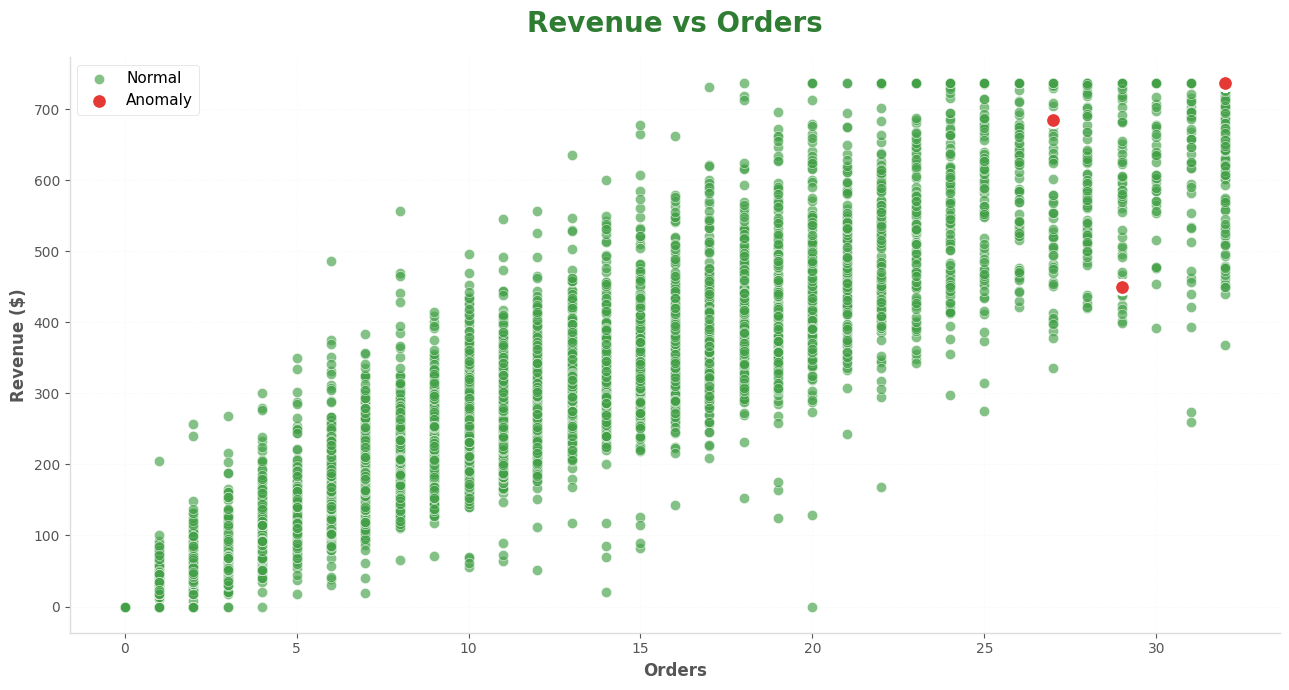

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import matplotlib.pyplot as plt
from google.colab import files

# ==========================
# Colors
# ==========================
GREEN = "#43A047"
GREEN_DARK = "#2E7D32"
GREEN_LIGHT = "#81C784"
RED = "#E53935"
BG = "#FFFFFF"
GRID = "#E8F5E9"

# ==========================
# Data
# ==========================
normal = df[df["Anomaly"] == 0]
anomaly = df[df["Anomaly"] == 1]

# ==========================
# Figure
# ==========================
fig, ax = plt.subplots(figsize=(13,7), facecolor=BG)

ax.set_facecolor(BG)

# ==========================
# Normal Points
# ==========================
ax.scatter(
    normal["Orders"],
    normal["Revenue"],
    s=55,
    color=GREEN,
    alpha=0.65,
    edgecolors="white",
    linewidth=0.5,
    label="Normal"
)

# ==========================
# Anomaly Points
# ==========================
ax.scatter(
    anomaly["Orders"],
    anomaly["Revenue"],
    s=120,
    color=RED,
    edgecolors="white",
    linewidth=1.8,
    alpha=1,
    label="Anomaly",
    zorder=5
)

# ==========================
# Title
# ==========================
ax.set_title(
    "Revenue vs Orders",
    fontsize=20,
    fontweight="bold",
    color=GREEN_DARK,
    pad=18
)

# ==========================
# Labels
# ==========================
ax.set_xlabel(
    "Orders",
    fontsize=12,
    fontweight="bold"
)

ax.set_ylabel(
    "Revenue ($)",
    fontsize=12,
    fontweight="bold"
)

# ==========================
# Grid
# ==========================
ax.grid(
    linestyle="--",
    linewidth=0.7,
    alpha=0.30,
    color=GRID
)

# ==========================
# Borders
# ==========================
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.spines["left"].set_color("#DDDDDD")
ax.spines["bottom"].set_color("#DDDDDD")

# ==========================
# Tick Style
# ==========================
ax.tick_params(axis="both", labelsize=10)

# ==========================
# Legend
# ==========================
legend = ax.legend(
    loc="upper left",
    fontsize=11,
    frameon=True
)

legend.get_frame().set_facecolor("white")
legend.get_frame().set_edgecolor("#DDDDDD")
legend.get_frame().set_alpha(1)

# ==========================
# Save Image
# ==========================
plt.tight_layout()

file_name = "Revenue_vs_Orders.png"

plt.savefig(
    file_name,
    dpi=600,
    bbox_inches="tight",
    facecolor="white"
)

plt.show()
plt.close(fig)

# ==========================
# Download
# ==========================
files.download(file_name)

Daily Anomaly Count

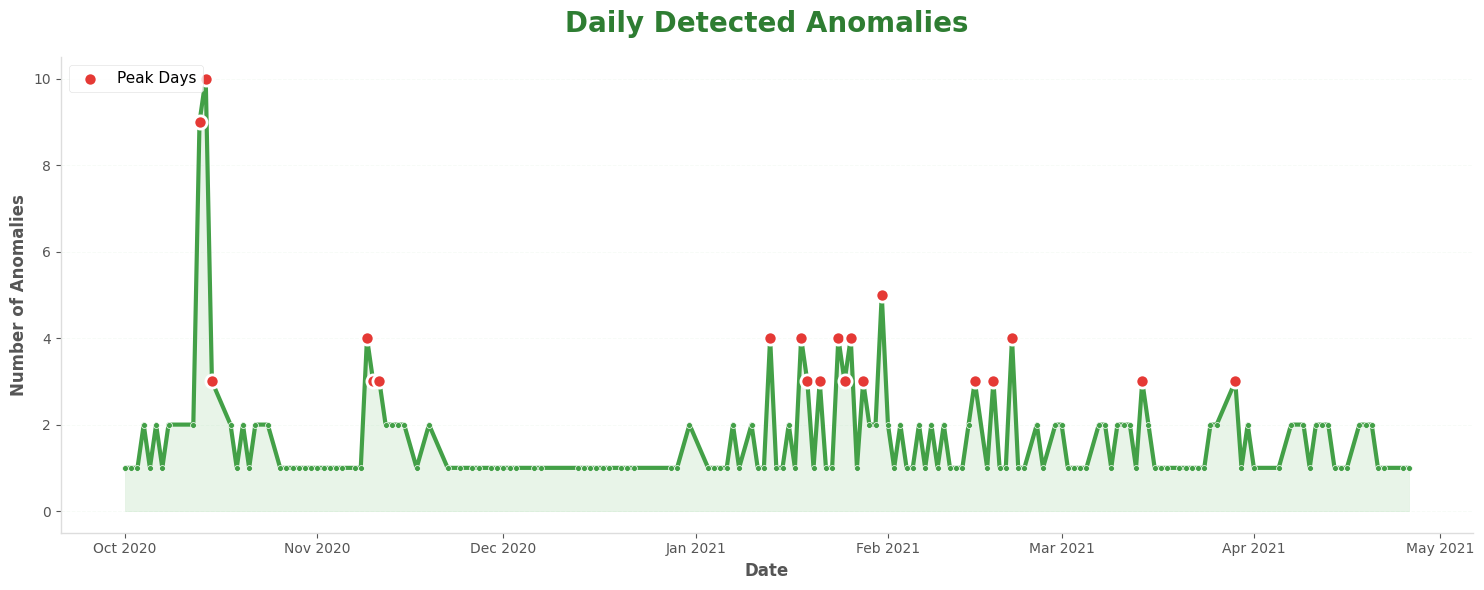

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from google.colab import files

# ==========================
# Colors
# ==========================
GREEN = "#43A047"
GREEN_DARK = "#2E7D32"
GREEN_LIGHT = "#81C784"
RED = "#E53935"
BG = "#FFFFFF"
GRID = "#E8F5E9"

# ==========================
# Daily Anomalies
# ==========================
daily_anomalies = (
    df[df["Anomaly"] == 1]
    .groupby("Date")
    .size()
    .sort_index()
)

threshold = daily_anomalies.quantile(0.90)
peaks = daily_anomalies[daily_anomalies >= threshold]

# ==========================
# Figure
# ==========================
fig, ax = plt.subplots(figsize=(15,6), facecolor=BG)

ax.set_facecolor(BG)

# Area
ax.fill_between(
    daily_anomalies.index,
    daily_anomalies.values,
    color=GREEN_LIGHT,
    alpha=0.18
)

# Line
ax.plot(
    daily_anomalies.index,
    daily_anomalies.values,
    color=GREEN,
    linewidth=3,
    solid_capstyle="round"
)

# Normal Points
ax.scatter(
    daily_anomalies.index,
    daily_anomalies.values,
    color=GREEN,
    s=18,
    edgecolors="white",
    linewidth=0.5,
    zorder=3
)

# Peak Points
ax.scatter(
    peaks.index,
    peaks.values,
    color=RED,
    s=90,
    edgecolors="white",
    linewidth=2,
    zorder=5,
    label="Peak Days"
)

# ==========================
# Title
# ==========================
ax.set_title(
    "Daily Detected Anomalies",
    fontsize=20,
    fontweight="bold",
    color=GREEN_DARK,
    pad=18
)

# ==========================
# Labels
# ==========================
ax.set_xlabel(
    "Date",
    fontsize=12,
    fontweight="bold"
)

ax.set_ylabel(
    "Number of Anomalies",
    fontsize=12,
    fontweight="bold"
)

# ==========================
# Date Format
# ==========================
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))

plt.xticks(rotation=0)

# ==========================
# Grid
# ==========================
ax.grid(
    axis="y",
    linestyle="--",
    linewidth=0.7,
    alpha=0.35,
    color=GRID
)

# ==========================
# Borders
# ==========================
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_color("#DDDDDD")
ax.spines["bottom"].set_color("#DDDDDD")

# ==========================
# Legend
# ==========================
legend = ax.legend(
    loc="upper left",
    frameon=True,
    fontsize=11
)

legend.get_frame().set_facecolor("white")
legend.get_frame().set_edgecolor("#DDDDDD")

# ==========================
# Tick Style
# ==========================
ax.tick_params(axis="x", labelsize=10)
ax.tick_params(axis="y", labelsize=10)

plt.tight_layout()

# ==========================
# Save Image
# ==========================
file_name = "Daily_Detected_Anomalies.png"

plt.savefig(
    file_name,
    dpi=600,
    bbox_inches="tight",
    facecolor="white"
)

plt.show()
plt.close(fig)

# ==========================
# Download Image
# ==========================
files.download(file_name)